<a href="https://colab.research.google.com/github/arthireddy14/Datasets_practice/blob/main/Matplotlib_tip_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install matplotlib

In [ ]:
import matplotlib.pyplot as plt

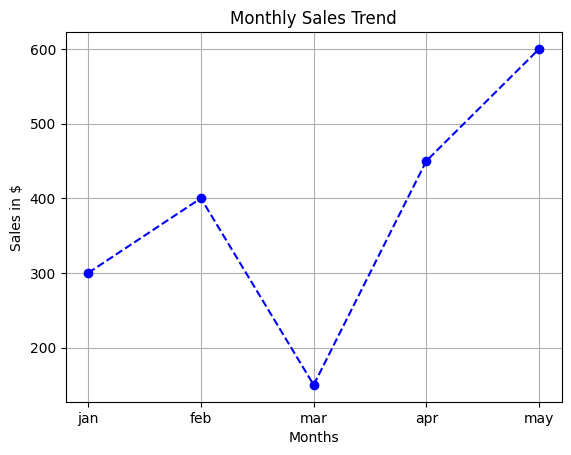

In [ ]:
#line plot
months=['jan','feb','mar','apr','may']
sales=[300,400,150,450,600]
plt.plot(months,sales,color='blue',marker='o',linestyle='--')
plt.title("Monthly Sales Trend")
plt.xlabel("Months")
plt.ylabel("Sales in $")
plt.grid(True)
plt.show()

Bar chart

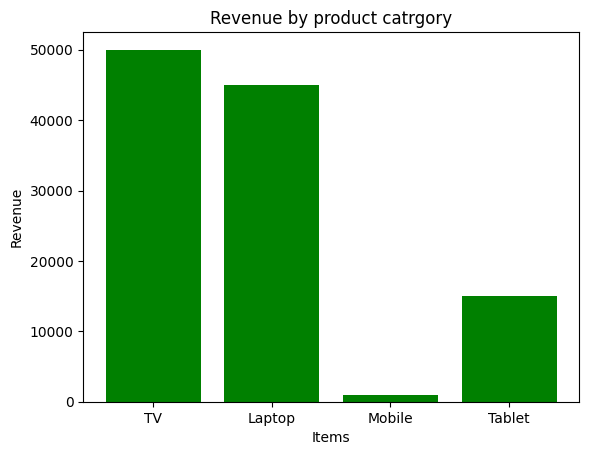

In [ ]:
items=['TV','Laptop','Mobile','Tablet']
revenue=[50000,45000,1000,15000]
plt.bar(items,revenue,color='green')
plt.title("Revenue by product catrgory")
plt.xlabel('Items')
plt.ylabel('Revenue')
plt.show()


Scatter plot

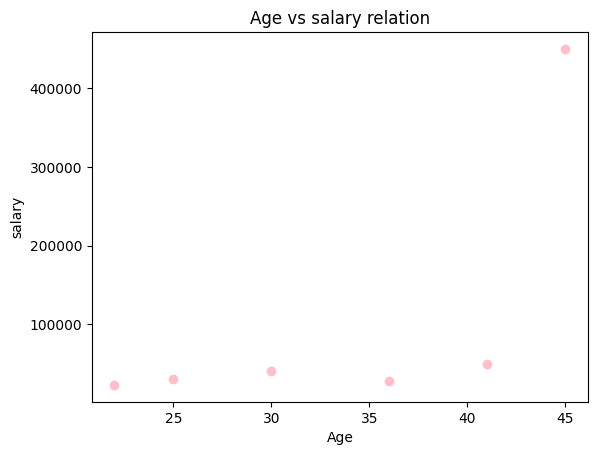

In [ ]:
import numpy as np
age=np.array([22,25,30,36,45,41])
salary=np.array([23000,30000,41000,28000,450000,50000])
plt.scatter(age,salary,color='pink')
plt.title("Age vs salary relation")
plt.xlabel("Age")
plt.ylabel("salary")
plt.show()

Pie chart

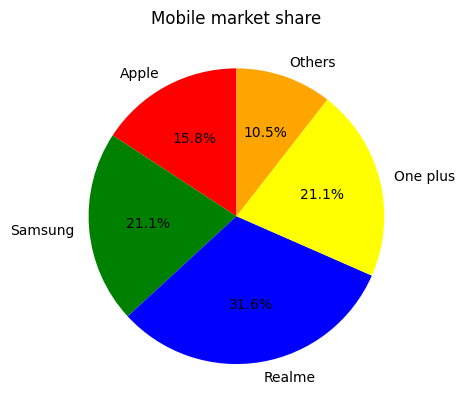

In [ ]:
brands=['Apple','Samsung','Realme','One plus','Others']
market_share=[30,40,60,40,20]
colors=['red','green','blue','yellow','orange']
plt.pie(market_share,labels=brands,colors=colors,autopct='%1.1f%%',startangle=90)
plt.title("Mobile market share")
plt.show()

Histogram

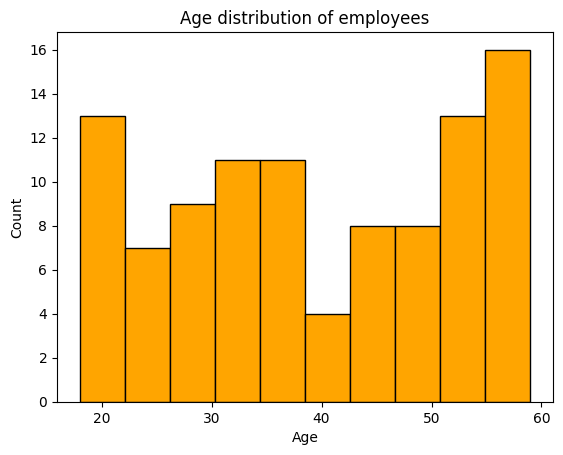

In [ ]:
ages=np.random.randint(18,60,100)
plt.hist(ages,bins=10,color='orange',edgecolor='black')
plt.title("Age distribution of employees")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Subplot

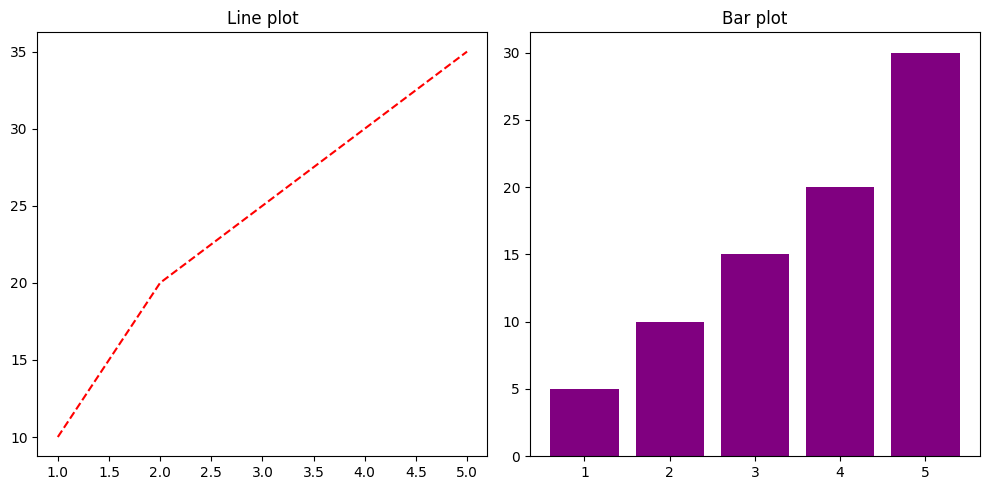

In [ ]:
x=[1,2,3,4,5]
y1=[10,20,25,30,35]
y2=[5,10,15,20,30]
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)#1 row,2 columns, first column
plt.plot(x,y1,'r--')
plt.title("Line plot")
plt.subplot(1,2,2)# 1 row,2 columns,second column
plt.bar(x,y2,color='purple')
plt.title("Bar plot")
plt.tight_layout()
plt.show()

Styles,Legends,

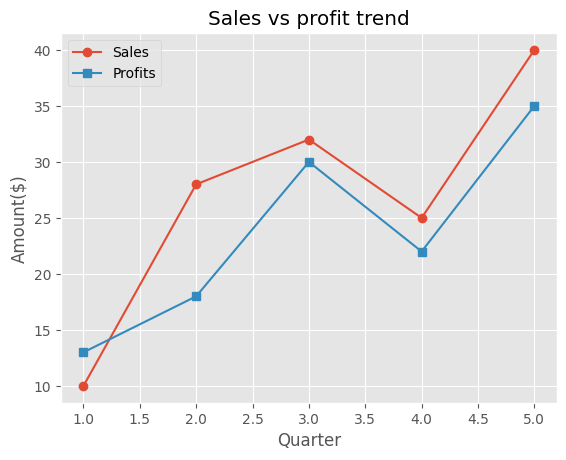

In [ ]:
plt.style.use('ggplot')
x=[1,2,3,4,5]
sales=[10,28,32,25,40]
profits=[13,18,30,22,35]
plt.plot(x,sales,label='Sales',marker='o')
plt.plot(x,profits,label='Profits',marker='s')
plt.title("Sales vs profit trend")
plt.xlabel("Quarter")
plt.ylabel('Amount($)')
plt.legend()
plt.savefig("sales_profitchart.png")#save the plot
plt.show()

•  Inspect the dataset and list the number of rows, columns, data types, and any missing values.
•  Remove duplicate rows (if any) and re-check the dataset — how many rows were removed?
•  Parse the Date column to datetime, sort the data by date, and report how many rows (if any) have invalid/missing dates.
•  Handle missing values in numeric columns (explain and apply a method you choose), then state which method you used and why.


In [ ]:
import pandas as pd
df=pd.read_csv('data.csv')
df.head()

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020/12/01,110,130,409.1
1,60,2020/12/02,117,145,479.0
2,60,2020/12/03,103,135,340.0
3,45,2020/12/04,109,175,282.4
4,45,2020/12/05,117,148,406.0


In [ ]:
df.isnull()


,Duration,Date,Pulse,Maxpulse,Calories
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,False,False,False,False,False
6,False,False,False,False,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Duration,0
Date,1
Pulse,0
Maxpulse,0
Calories,2


In [ ]:
df.shape


(32, 5)

In [ ]:
df.dtypes

,0
Duration,int64
Date,object
Pulse,int64
Maxpulse,int64
Calories,float64


In [ ]:
duplicates=df.duplicated().sum()
print(duplicates)

1


In [ ]:
df=df.drop_duplicates()
print("New shape will be ",df.shape)

New shape will be  (31, 5)


In [ ]:
df['Date']=pd.to_datetime(df['Date'],errors='coerce')
invalid_dates=df['Date'].isnull().sum()
print("Number of invalid dates",invalid_dates)

Number of invalid dates 1


In [ ]:
df=df.sort_values('Date')

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

# Check missing values
print("Missing values in numeric columns:\n", df[numeric_cols].isnull().sum())

# Fill missing values using mean imputation
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print("Missing values after imputation:\n", df[numeric_cols].isnull().sum())

Missing values in numeric columns:
 Duration    0
Pulse       0
Maxpulse    0
Calories    2
dtype: int64
Missing values after imputation:
 Duration    0
Pulse       0
Maxpulse    0
Calories    0
dtype: int64


Create a line plot of Calories over Date (with markers, dashed line, grid, rotated x-ticks) and save the image as line_calories_over_time.png.


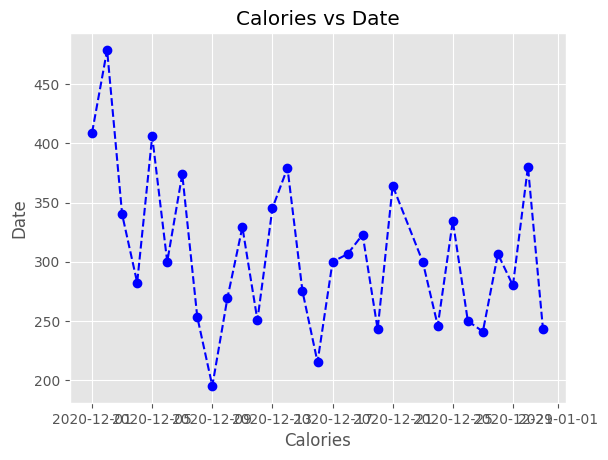

In [ ]:
plt.plot(df['Date'],df['Calories'],marker='o',linestyle='--',color='blue')
plt.title("Calories vs Date")
plt.xlabel("Calories")
plt.ylabel("Date")
plt.grid(True)
plt.savefig("line_calories_dates.png")#save the plot
plt.show()


Group data by Duration (or sensible duration bins), compute the average Pulse per group, and draw a bar chart comparing average pulse across duration groups; save as bar_avg_pulse_by_duration.png

/tmp/ipython-input-1232935185.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_pulse = df.groupby('Duration_bin')['Pulse'].mean().reset_index()


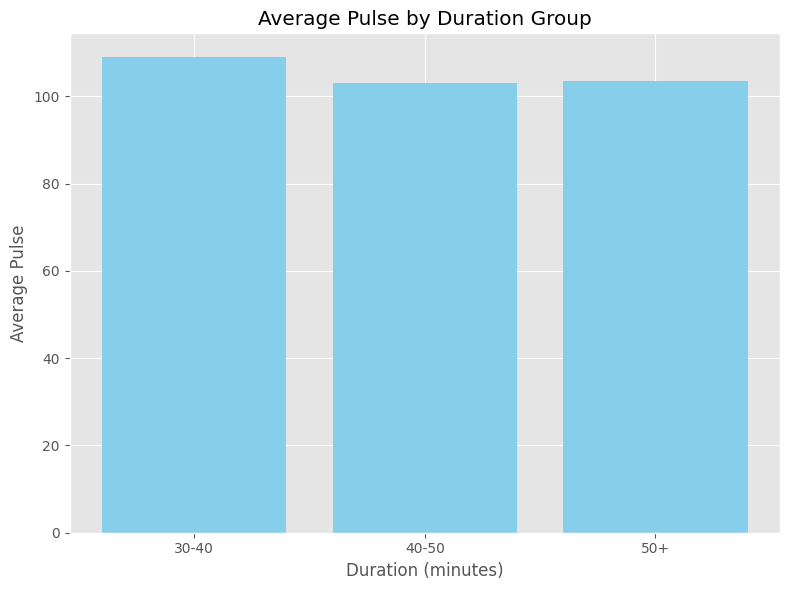

In [ ]:
# bins=[10,20,30,40,50]
# labels=['0-10','10-20','20-30','30-40','50+']
# df['Duration_bins']=pd.cut(df['Duration'],bins=bins,labels=labels,right=False)
# avg_pulse=df.groupby('Duration_bins')('Pulse').mean()
# plt.figure(figsize=(8,6))
# plt.bar(avg_pulse['Duration_bins'],avg_pulse('Pulse'),color='green')
# plt.title("Average Pulse by Duration")
# plt.xlabel("Duration")
# plt.ylabel("Average Pulse")
# plt.tight_layout()
# plt.savefig("bar_avg_pulse_by_duration.png")
# plt.show()
bins = [0, 10, 20, 30, 40, 50, float('inf')]
labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50+']
df['Duration_bin'] = pd.cut(df['Duration'], bins=bins, labels=labels, right=False)

# Group by duration bins and calculate average pulse
avg_pulse = df.groupby('Duration_bin')['Pulse'].mean().reset_index()

# Plot bar chart
plt.figure(figsize=(8, 6))
plt.bar(avg_pulse['Duration_bin'], avg_pulse['Pulse'], color='skyblue')
plt.xlabel('Duration (minutes)')
plt.ylabel('Average Pulse')
plt.title('Average Pulse by Duration Group')
plt.tight_layout()

# Save the chart
plt.savefig('bar_avg_pulse_by_duration.png')
plt.show()


  Plot a scatter plot of Duration vs Calories, compute the Pearson correlation coefficient, and add a linear trend line to the scatter; save as scatter_duration_vs_calories.png

In [ ]:
# plt.scatter(df['Duration'],df['Calories'],color='red')
# Drop rows with missing Duration or Calories
df_clean = df.dropna(subset=['Duration', 'Calories'])

# Compute Pearson correlation
corr, _ = pearsonr(df_clean['Duration'], df_clean['Calories'])
print(f"Pearson correlation coefficient: {corr:.3f}")

# Plot scatter with trend line
plt.figure(figsize=(8, 6))
sns.regplot(x='Duration', y='Calories', data=df_clean, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.title('Duration vs Calories\n(Pearson r = {:.3f})'.format(corr))
plt.xlabel('Duration (minutes)')
plt.ylabel('Calories burned')
plt.tight_layout()

# Save the plot
plt.savefig('scatter_duration_vs_calories.png')
plt.show()

NameError: name 'pearsonr' is not defined

Create a pie chart showing the percentage breakdown of Maxpulse into ranges (e.g., <=120, 121–140, 141–160, >160) and save as pie_maxpulse_ranges.png

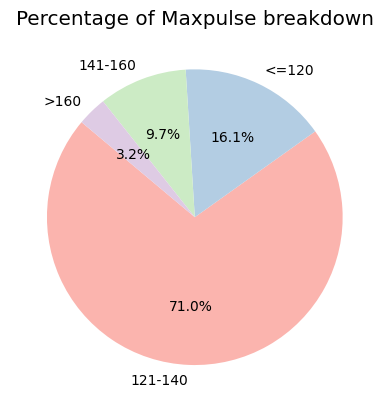

In [ ]:
bins=[0,120,140,160,float('inf')]
labels=['<=120','121-140','141-160','>160']
df['Maxpulse_range']=pd.cut(df['Maxpulse'],bins=bins,labels=labels,right=False)
ranges=df['Maxpulse_range'].value_counts(normalize=True)*100
plt.pie(ranges,labels=ranges.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
plt.title("Percentage of Maxpulse breakdown")
plt.savefig("pie_maxpulse_ranges.png")
plt.show()


Plot a histogram of Calories with an appropriate number of bins, comment on shape/skewness, and save as hist_calories.png.

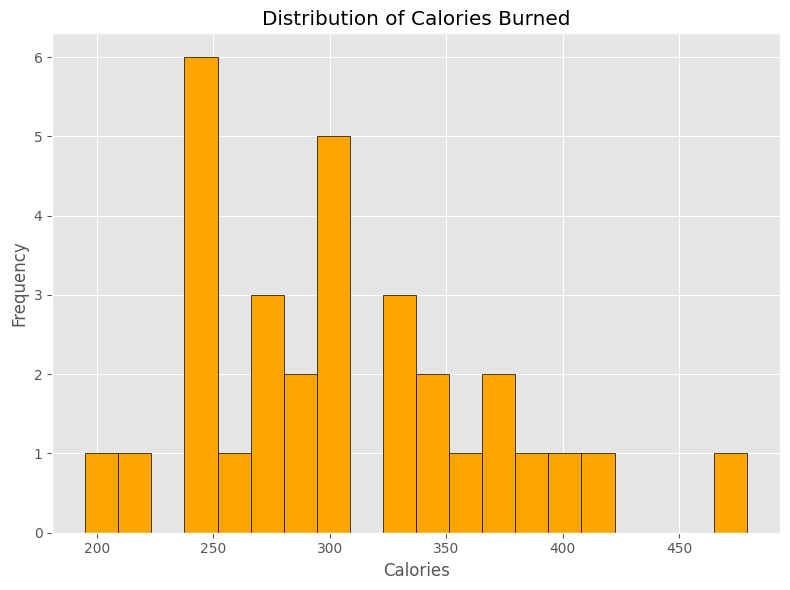

Skewness of Calories: 0.65
The distribution is right-skewed (positively skewed).


In [ ]:
# plt.figure(figsize=(8,6))
# plt.hist(df['Calories'],bins=10,color='skyblue',edgecolor='black')
# plt.title("Distribution of Calories")
# plt.xlabel("Calories")
# plt.ylabel("Freq")
# plt.tight_layout()
# plt.savefig("hist_calories.png")
# plt.show()
# Drop missing values in Calories
df_clean = df.dropna(subset=['Calories'])

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(df_clean['Calories'], bins=20, color='orange', edgecolor='black')
plt.title('Distribution of Calories Burned')
plt.xlabel('Calories')
plt.ylabel('Frequency')
plt.tight_layout()

# Save the histogram
plt.savefig('hist_calories.png')
plt.show()

# Comment on shape/skewness
skewness = df_clean['Calories'].skew()
print(f"Skewness of Calories: {skewness:.2f}")
if skewness > 0.5:
    print("The distribution is right-skewed (positively skewed).")
elif skewness < -0.5:
    print("The distribution is left-skewed (negatively skewed).")
else:
    print("The distribution is approximately symmetric.")

Build a multi-panel subplot figure (1 row × 2 columns): left = line plot of Pulse over Date, right = scatter of Duration vs Maxpulse; save as subplots_pulse_duration_maxpulse.png

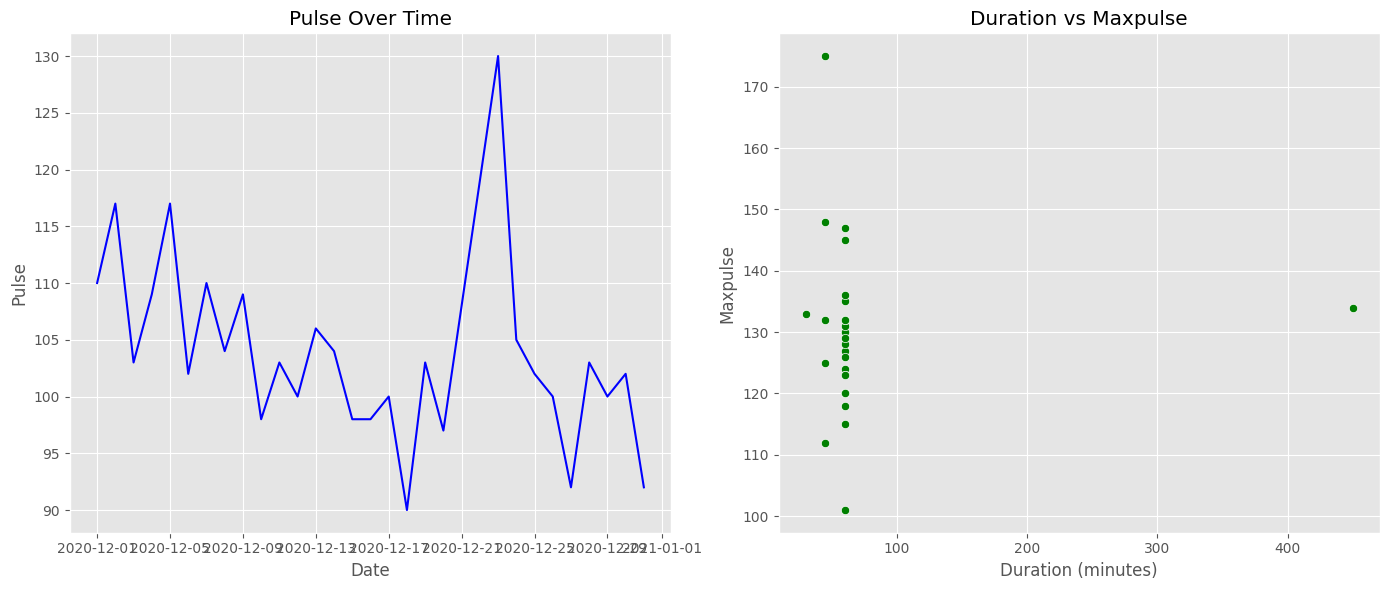

In [ ]:
# plt.figure(figsize=(8,6))
# plt.subplot(1,2,1)#1 row,2 columns, first column
# plt.plot(df['Pulse'],df['Date'],color='blue')
# plt.title("Line plot-Pulse vs Date")
# plt.subplot(1,2,2)# 1 row,2 columns,second column
# plt.scatter(df['Duration'],df['Maxpulse'],color='purple')
# plt.title("Scatter plot-Duration vs Maxpulse")
import seaborn as sns

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop rows with missing values in relevant columns
df_plot = df.dropna(subset=['Date', 'Pulse', 'Duration', 'Maxpulse'])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Line plot of Pulse over Date
sns.lineplot(ax=axes[0], x='Date', y='Pulse', data=df_plot, color='blue')
axes[0].set_title('Pulse Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Pulse')

# Right: Scatter plot of Duration vs Maxpulse
sns.scatterplot(ax=axes[1], x='Duration', y='Maxpulse', data=df_plot, color='green')
axes[1].set_title('Duration vs Maxpulse')
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_ylabel('Maxpulse')
plt.tight_layout()
plt.savefig("subplots_pulseduration.png")
plt.show()

1. Basic Data Understanding

What does the dataset look like?

What are the column names, data types, and basic statistics?

Are there missing values or anomalies?

((No plot required — just inspection using Pandas.)



 2. Trend Analysis

How does a numerical variable (e.g., Sales) change over time or index?

Are there visible upward or downward trends?

Are there any noticeable spikes, dips, or seasonality?

lineplot



 3. Category Comparison

Which category (e.g., Region, Product, Department) contributes most to the total value?

Which categories have lower contributions?

How big is the gap between categories?

barplot



 4. Value Distribution

How are values in a numerical column distributed?

Are they concentrated around certain ranges or spread out evenly?

Are there extreme values?

histplot



 5. Relationship Between Variables

How does one numerical variable relate to another (e.g., Sales vs Profit)?

Is there any visible correlation?

Are there outliers?

scatterplot



 6. Outliers & Spread

How spread out are values in a numerical column?

Are there any outliers?

How does this spread differ across categories?

boxplot



 7. Proportions

How is the dataset divided among different categories?

Which category has the largest share?

Is the distribution balanced or skewed?

pieplot

 8. Multiple Visuals in One View

How do multiple insights look side by side?

Can we spot patterns when trend, distribution, and relationships are combined visually?

Which plot gives the clearest story?

subplots





 9. Final Task Submission

Your final notebook/script must include:

All questions answered with appropriate Matplotlib  plots.

Proper customization (titles, labels, legends, grids).

A short written note (markdown ) under each plot describing what the plot reveals.

All code should be your own — no Seaborn or external visualization libraries

In [ ]:
#tip.csv file
import pandas as pd
import numpy as np
df=pd.read_csv('tip(in).csv')
df.shape


(244, 7)

In [ ]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [ ]:
df.dtypes

,0
total_bill,float64
tip,float64
sex,object
smoker,object
day,object
time,object
size,int64


In [ ]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [ ]:
df.isnull()

,total_bill,tip,sex,smoker,day,time,size
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
239,False,False,False,False,False,False,False
240,False,False,False,False,False,False,False
241,False,False,False,False,False,False,False
242,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


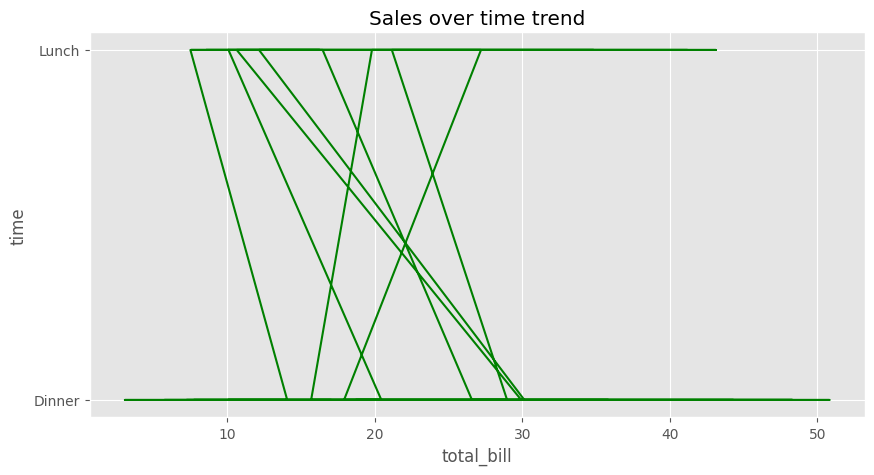

In [ ]:

plt.figure(figsize=(10,5))
plt.plot(df['total_bill'],df['time'],color='green')
plt.title("Sales over time trend")
plt.xlabel("total_bill")
plt.ylabel("time")
plt.grid(True)
plt.show()

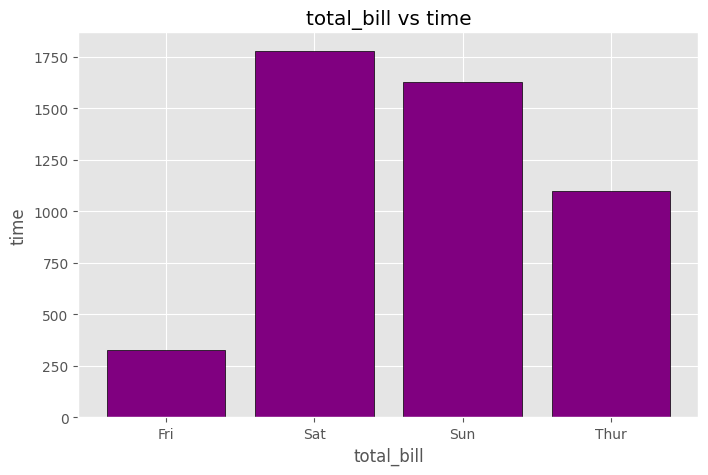

In [ ]:
total_by_day = df.groupby('day')['total_bill'].sum()

plt.figure(figsize=(8,5))
plt.bar(total_by_day.index, total_by_day.values,color='purple',edgecolor='black')
plt.title("total_bill vs time")
plt.xlabel("total_bill")
plt.ylabel("time")
plt.show()